### The work you did previously was on a dataset containing only star forming galaxies. Those galaxies were relatively low redshift (0.5 < z) which means that we can apply standard methods to identify star forming galaxies. As we approach higher redshifts and galaxies become more distant it gets much harder to pick out the star forming galaxies. The galaxies you will look at today are in the redshift range 0.5<z<1. In this notebook you will learn how to pick out star forming galaxies from a sample of higher redshift objects. When you have filtered your data you will also undertake the challenge of calculating star formation rates for these more distant galaxies.

### **Why is it more difficult to work with higher redshift galaxies?**

### **The expansion of the universe!**

### Telescopes are designed to be able to detect light at a range of wavelengths, there is some maximum wavelength at which a telescope can still detect light. More distant galaxies are more redshifted, this means that the wavelength of light is stretched. If the wavelength is stretched beyond the detection limit of a telescope we can no longer see it! For DESI, H$\alpha$ emission is stretched beyond detection limits beyond redshift 0.5 so we have to change our approach.

### **What do we need to filter out of the data?**

### We need to get rid of galaxies that are not forming stars, these galaxies could skew our data and produce incorrect results. The main type of galaxy that we want to remove from our sample is AGN (Active Galactic Nuclei). These galaxies have black holes at their centres which are actively pulling in matter, this matter gets hot and excited and emits light. We need to remove these galaxies from our sample so that we don't mistake the light emit for star light. The image below shows an AGN.

![AGN](https://aasnova.org/wp-content/uploads/2019/08/800px-ESO_Centaurus_A_LABOCA.jpg)

In [6]:
#firstly we import all of the modules we need for this session

import fitsio
from astropy.table import Table, unique, vstack, join
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import astropy.units as u
import seaborn as sns
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

In [7]:
# firstly we read in our data file 
table = fitsio.read('/Users/amara/Documents/PhD/Outreach/In2STEM/high_z_sample.fits')
data = Table(table)

In [8]:
#data #uncomment this line to view a preview of the table

### How do we filter out AGN?

### We use what is called a Mass-Excitation (MEx) diagnostic. We plot the ratio of two emission lines OII and H$\beta$ against the mass of a galaxy and the position of the galaxy on this plot determines whether it is an AGN or a star forming galaxy. Essentially, we set a threshold to define the limit for an AGN. Galaxies with log([OIII]/H$\beta$) ratios greater than the defined limits are classified as AGN dominated and are excluded.

### Here is the equation that we use:

$$ \log\left (   \frac{O\:III}{H\beta} \right) > \frac{0.37}{x - 10.5 } + 1 $$

Where x =  log($M_{*}$) and valid in the regime where log($M_{*}$) $\leq$ 9.9

For galaxies with log($M_{*}$) > 9.9 the threshold is:

$$ \log\left (   \frac{O\:III}{H\beta} \right) > 800.492 - 217.328x + 19.6431x^{2} - 0.591349x^{3} $$

### The OIII flux is contained in the data table as data['OIII_5007'] and H$\beta$ is data['HBETA_FLUX']. The mass is already in log form in the table ans is called data['LOGMSTAR'].}$$$$

In [10]:
#in this code you will work out the above inequality calculaitons 

# write some code to calculate log of the ratio of OIII and H beta flux

log_ratio = 

#saving this to the table 

data['LOG_RATIO'] = log_ratio

# here we separate the galaxies based on their mass according to the the above limits 

low_mass = data['LOGMSTAR'] <= 9.9
high_mass = data['LOGMSTAR'] > 9.9 

# write some code to calculate the value of the right hand side of the low mass inequality it will be more simple if we define
# the mass as x 

x_low = data['LOGMSTAR'][low_mass]
x_high = data['LOGMSTAR'][high_mass]

low_mass_RHS = 
high_mass_RHS = 

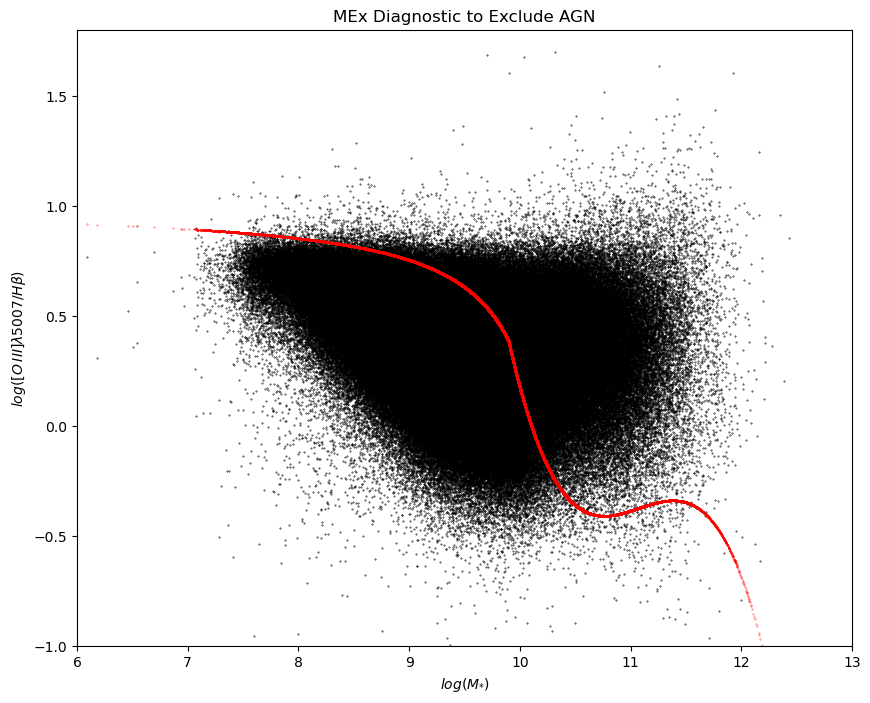

Galaxies below the red line are considered star forming


In [11]:
#now we can plot the MEx diagram and see which galaxies we need to remove from our sample

fig = plt.figure(figsize = (10, 8))

#we want to plot the log ratio calculation on the y axis and log mass on the x axis

plt.plot(data['LOGMSTAR'], log_ratio , '.' ,markersize = 0.7, color = 'black')

# adding a line to the plot to show the separation of galaxies

plt.plot(x_low, low_mass_RHS,   '.' , markersize = 0.5, color = 'red' )
plt.plot(x_high , high_mass_RHS, '.' , markersize = 0.5, color = 'red')

#figure details 
plt.title('MEx Diagnostic to Exclude AGN')
plt.xlabel(r'$log(M_{*})$')
plt.ylabel(r'$log([O\:III]\lambda5007/Hβ)$')
plt.xlim(6,13)
plt.ylim(-1,1.8)

plt.show()

print('Galaxies below the red line are considered star forming')

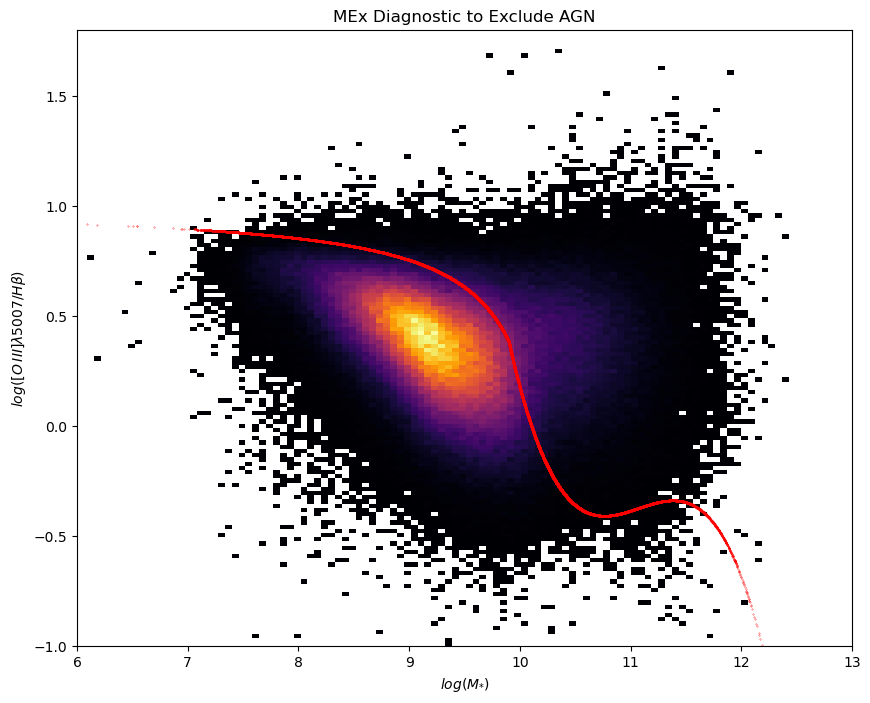

Galaxies below the red line are considered star forming


In [12]:
# In this cell we plot a 2d histogram which shows the density of points. This allows us to see where most of the 
#galaxies are on the plot

fig = plt.figure(figsize=(10, 8))

# Create the 2D histogram density plot
plt.hist2d(data['LOGMSTAR'], log_ratio, bins =200,cmin =1, cmap='inferno')

# Add the red line to the plot
plt.plot(x_low, low_mass_RHS, '.', markersize=0.5, color='red')
plt.plot(x_high, high_mass_RHS, '.', markersize=0.5, color='red')

# Figure details
plt.title('MEx Diagnostic to Exclude AGN')
plt.xlabel(r'$log(M_{*})$')
plt.ylabel(r'$log([O\:III]\lambda5007/Hβ)$')
plt.xlim(6, 13)
plt.ylim(-1, 1.8)


plt.show()

print('Galaxies below the red line are considered star forming')

### Why is it useful to make a plot showing the concentration of galaxies?

In [14]:
# This code removes the AGNs from the sample by adding a true or false label to each galaxy. True means AGN, false 
# means star forming.

# we start by adding a column for the AGN result and set all to false to start
data['AGN_RESULT'] = False

# Marking AGNs as true

data['AGN_RESULT'][low_mass] = data['LOG_RATIO'][low_mass] > low_mass_RHS
data['AGN_RESULT'][high_mass] = data['LOG_RATIO'][high_mass] > high_mass_RHS

#separating galaxies
agn = data['AGN_RESULT']
agn_galaxies = data[agn]
star_forming_galaxies = data[~agn]

In [15]:
#write some code to work out the percentage of galaxies that were found to be AGN and display it. Hint: len(agn_galaxies) will give the number
# of agn and len(star_forming_galaxies) will give the number of star forming galaxies 

agn_percentage = 


27.828198900677492


### Using the H$\beta$ emission line is not as accurate as using the H$\alpha$ emission. To try and reduce errors we need to cut down our sample to only contains galaxies which have very good H$\beta$ emission signal strength. We do this by calculating the signal to noise ratio. The signal is the flux of the emission line and the noise is the spread of signal around the line. The image below shows what a spectrum from a galaxy might look like. In the spectrum we can see the H$\beta$ line and other emission lines, but we can also see lots of peaks and troughs around these lines, this is noise. In the example spectrium below, H$\alpha$ has a very strong signal, much stronger than the noise around it so this galaxy would have a high H$\alpha$ signal to noise ratio.

![spectrum](https://www.shelyak.com/wp-content/uploads/Graphe_2E3934-1.png)

### A signal to noise ratio of 10 for H$\gamma$ and 3 for H$\beta$ should be enough to get good results but you might find otherwise and need to come back to change it. The code below will cut down our sample size by filtering out galaxies with poor signals, but it will improve the accuracy of our results.

$$ \text{Signal to Noise Ratio} = \frac{\text{Flux}}{\sqrt{\text{Inverse Variance of Flux}}}$$

The inverse variance of flux is in the table as ['HBETA/HGAMMA_FLUX_IVAR']

In [19]:
# write some code to calcaulate the signal to noise ratio of H beta

s_n_beta = 

# write some code to calcaulate the signal to noise ratio of H gamma

s_n_gamma = 

# the line of code below filters out galaxies with low signal to noise ratio

h_beta_filter = s_n_beta >  #add desired threshold
h_gamma_filter = s_n_gamma  >   #add desired threshold

#the lines below combine and apply the signal to noise filter
filter = h_beta_filter & h_gamma_filter
data = data[filter]

print('There are', len(data),'galaxies remaining after filtering')

There are 48487 galaxies remaining after filtering


### **How does removing galxies with weak signals affect our sample?**

### How many galaxies have we lost?
### How do we decide when to make cuts like this instead of prioritsing a large sample size?

### Now you will calculate the star formation rates of these galaxies using the H$\beta$ emission line. The process is similar to using H$\alpha$. Once again, we first calculate the attenuation.

$$ A(H\beta )[mag] = \frac{2.5log(\frac{1}{2.13}\ \times \frac{F_{H\beta }}{F_{H\gamma }})}{\frac{k(H\gamma )}{k(H\beta )}-1} $$

Where

Where k(Hβ)/k(Hγ) = 1.157 from calculation

$\frac{F_{H\beta }}{F_{H\gamma }}$ is already in the data table as 'HGAMMA_BD'.

In [22]:
h_beta_attenuation = 

### Before the luminosity attenuation can be calculated the observed luminosity must be calculated using redshift

$$ Luminosity =  4 \times \pi \times (\text{luminosity distance})^2 \times \text{H$\beta$\:flux} $$

In [24]:
#calculating the luminosity distance in units of centimetres
dlum = cosmo.luminosity_distance(data['Z']).to(u.cm)

#defining Hβ flux and converting to correct units of ergs/cm^2/s
h_beta_flux = np.array(data['HBETA_FLUX']) * (1 * 10**-17)

#calculating the Hβ luminosity in units of ergs/s
luminosity_h_beta = 

#### Now calculating the attenuation corrected luminosity using: 

$$ L(H\beta )_{corr}= L(H\beta )_{obs} \times 10^{0.4A(H\beta )} $$

In [26]:
#calculating the corrected luminosity

luminosity_corrected = 

data['HBETA_LUMINOSITY'] = luminosity_corrected

#### Now the star formation rate can be calculated using: 
$$ SFR[M_{\odot}yr^{-1}] = (1.573 \times 10^{-41} ) \times L(H\beta )_{corr} $$

In [28]:
#write some code to calculate the star formation rate
sfr = 

#adding the values to the table 

data['SFR_CALCULATED'] = sfr

#### Now we will plot a histogram to show the distribution of our star formation rates. How does this compare with the lower redshift sample? Are you getting strange values? Increase the signal to noise ratio for the emission lines and see if that changes anything.

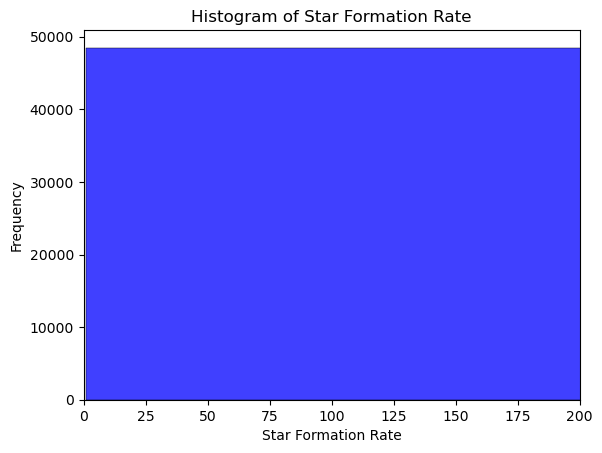

In [30]:
sns.histplot(data['SFR_CALCULATED'], bins=100, color='blue', edgecolor='black')

# Add labels and title
plt.xlabel('Star Formation Rate')
plt.ylabel('Frequency')
plt.xlim(0,200)
plt.title('Histogram of Star Formation Rate')

# Show the plot
plt.show()

### Let's compare the star formation rate trends with the low redshift sample

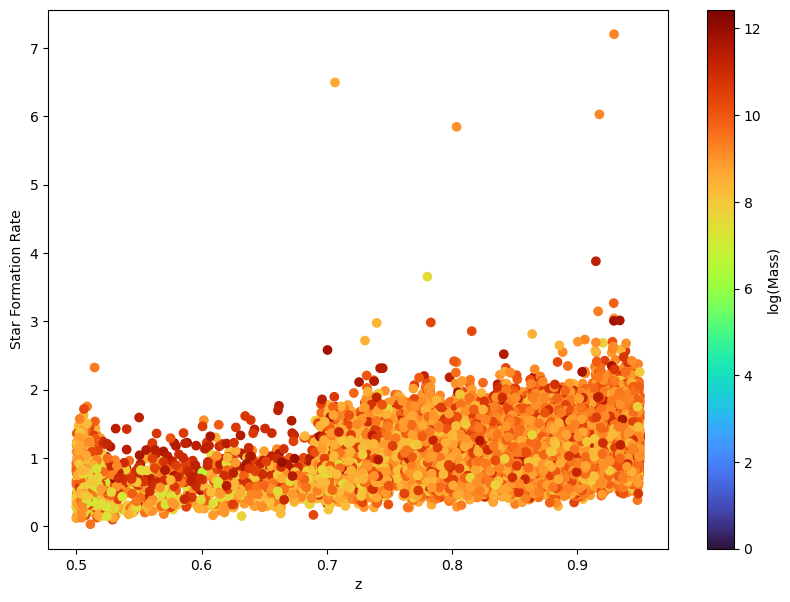

In [32]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    x=data['Z'],
    y=np.log10(sfr),
    c=data['LOGMSTAR'],
    cmap='turbo'
)

ax.set_xlabel('z')
ax.set_ylabel('Star Formation Rate')

plt.colorbar(scatter, label = 'log(Mass)',ax=ax)
plt.show()


### Like last time you will see how star formation rate trends with different quantities. The code cell below has the very basic outline for some code to plot different variable against each other, try plotting different quantities in the table against each other to see how they are correlated. Plot the same variables as you did with the low mass sample and see how the two compare. 

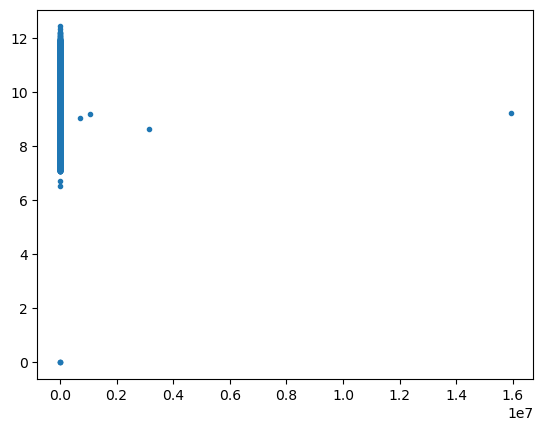

In [34]:
#change x and y to variables that you want to investigate. You might have to change the axes limits for it to make sense.
# remove the # to make the other lines active and add axes labels etc.

x = sfr
y = data['LOGMSTAR']

plt.plot(x, y , '.')
#plt.xlim(,)
#plt.ylim(,)
#plt.xlabel('')
#plt.ylabel('')

plt.show()